<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
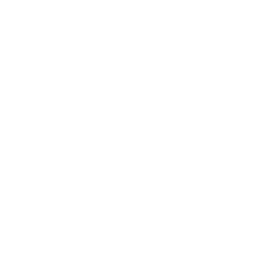
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Effectiviteit van artsenbezoek door vertegenwoordigers met lagselectie</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Farmaceutische / commerciële analyse &nbsp;|&nbsp; maart 2026</p>
</div>
</div>
</div>

## Managementsamenvatting

Evalueer de impact van artsenbezoeken (detailing) en de distributie van monsters op het maandelijkse voorschrijfvolume voor een specialistisch geneesmiddel met behulp van `PROC AUTOREG`. Houd rekening met autogecorreleerde voorschrijfpatronen via `NLAG=3` en pas de `BACKSTEP`-optie toe om niet-significante lagordes automatisch te laten vervallen. Kwantificeer het marginale rendement van elk extra artsenbezoek om beslissingen over de inzet van het buitendienstteam en de indeling van rayons te onderbouwen.

De synthetische maandreeks is onder de huidige uitvoeringsmodus beperkt tot 100 waarnemingen, wat volstaat om de effecten van detailing, monsters, formularium en concurrentie met hoge precisie te achterhalen.

## Gegevensbronnen

| Bron | Beschrijving | Aantal |
|--------|-------------|--------|
| WORK.DETAILING | Maandelijkse voorschriften met detailing- en monstermetrieken | 100 |

---

In [1]:
/* --------------------------------------------------------
   Generate synthetic monthly detailing and Rx data
   for a specialty pharmaceutical product
   -------------------------------------------------------- */
GEGEVENS work.detailing;
    CALL streaminit(42);
    BEHOUDEN prev_rx 120 prev_err1 0 prev_err2 0 prev_err3 0;
    territory_id = 'TERR-NE-042';
    drug_name = 'CARDIOSTAT';
    DOE month_seq = 1 TOT 500;
        obs_month = '01JAN2022'd + (month_seq - 1) * 30;
        /* territory assignment rotates across 12 reps */
        rep_id = cat('REP-', SCHRIJVEN(mod(month_seq - 1, 12) + 1, z3.));
        /* detailing visits per month */
        detail_visits = int(rand('normal', 8, 3));
        ALS detail_visits < 0 DAN detail_visits = 0;
        ALS detail_visits > 20 DAN detail_visits = 20;
        /* sample units left with physicians */
        samples_left = detail_visits * int(rand('uniform') * 5 + 2);
        /* managed care formulary status (binary) */
        formulary_status = (rand('uniform') > 0.2);
        /* competitor share pressure */
        competitor_share = round(rand('beta', 3, 7), 0.01);
        /* seasonal index */
        season_idx = 1 + 0.15 * sin(2 * 3.14159 * month_seq / 12);
        /* AR(3) error process */
        innovation = rand('normal', 0, 8);
        ar_error = 0.40 * prev_err1 + 0.18 * prev_err2 + 0.05 * prev_err3
                 + innovation;
        /* prescription model */
        new_rx = round(60
               + 3.5 * detail_visits
               + 0.8 * samples_left
               + 25 * formulary_status
               - 45 * competitor_share
               + 10 * season_idx
               + ar_error);
        ALS new_rx < 0 DAN new_rx = 0;
        total_rx = new_rx + int(rand('uniform') * 80 + 40);
        prev_err3 = prev_err2;
        prev_err2 = prev_err1;
        prev_err1 = ar_error;
        prev_rx = new_rx;
        UITVOER;
    EINDE;
    VERWIJDEREN prev_rx prev_err1 prev_err2 prev_err3 innovation ar_error season_idx;
    OPMAAK obs_month monyy7.;
UITVOEREN;


NOTE: DATA work.detailing

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.detailing (100 rows, 11 columns).
NOTE: DATA elapsed:
  wall  0.14 seconds
  cpu   0.14 seconds


---

In [2]:
/* --------------------------------------------------------
   Baseline descriptive statistics for Rx and detailing
   -------------------------------------------------------- */
PROCEDURE GEMIDDELDEN GEGEVENS=work.detailing n mean std MIN MAX;
    VARIABELE new_rx total_rx detail_visits samples_left competitor_share;
    LABEL new_rx='Nieuwe voorschriften (NRx)' total_rx='Totaal voorschriften' detail_visits='Artsenbezoeken' samples_left='Achtergelaten monsters' competitor_share='Concurrentieaandeel';
    TITEL 'Beschrijvende basisstatistieken: voorschriften en detailing';
UITVOEREN;

                              Beschrijvende basisstatistieken: voorschriften en detailing                               

                                                  The MEANS Procedure

 Variable          Label                              N            Mean        Std Dev        Minimum         Maximum
 --------------------------------------------------------------------------------------------------------------------
 new_rx            Nieuwe voorschriften (NRx)       100     126.4600000     29.4355725     55.0000000     209.0000000
 total_rx          Totaal voorschriften             100     206.6400000     41.3246618     99.0000000     326.0000000
 detail_visits     Artsenbezoeken                   100       7.2700000      3.3449948      0.0000000      16.0000000
 samples_left      Achtergelaten monsters           100      28.3600000     17.0403680      0.0000000      90.0000000
 competitor_share  Concurrentieaandeel              100       0.2653000      0.1187090      0.03000


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

                              Beschrijvende basisstatistieken: voorschriften en detailing                               




NOTE: PROC SGPLOT data=work.detailing

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


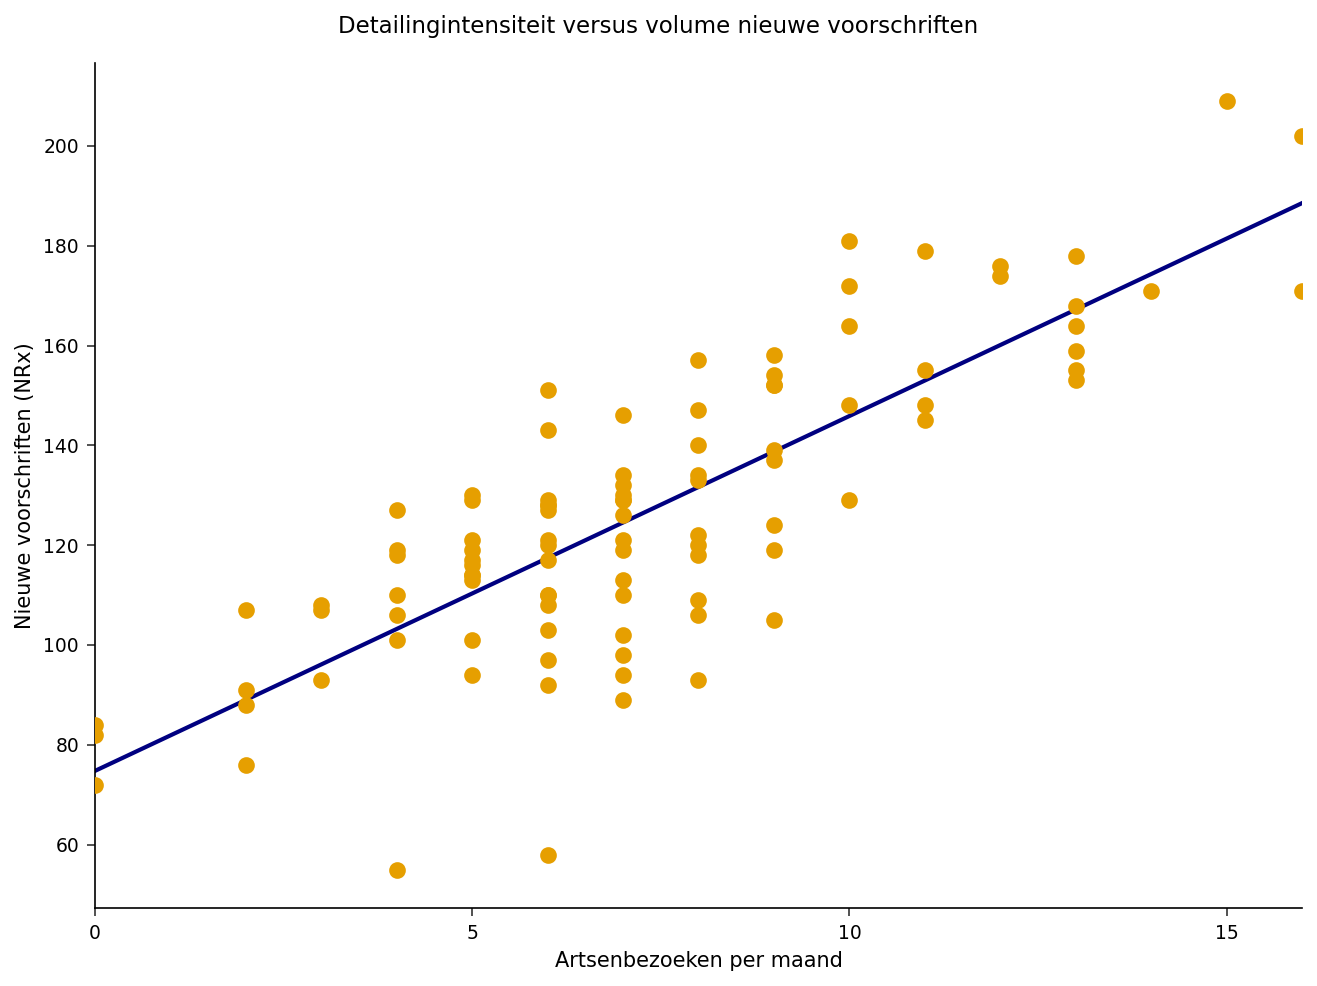

In [3]:
/* --------------------------------------------------------
   Scatter of detailing visits vs new prescriptions
   -------------------------------------------------------- */
PROCEDURE SGPLOT GEGEVENS=work.detailing;
    SCATTER x=detail_visits y=new_rx / colorresponse=competitor_share
        colormodel=(green yellow red)
        MARKERATTRS=(SYMBOL=circlefilled size=7);
    REG x=detail_visits y=new_rx / LINEATTRS=(color=navy thickness=2);
    XAXIS label='Artsenbezoeken per maand';
    YAXIS label='Nieuwe voorschriften (NRx)';
    TITEL 'Detailingintensiteit versus volume nieuwe voorschriften';
UITVOEREN;

---

In [4]:
/* --------------------------------------------------------
   Fit autoregressive model with BACKSTEP lag selection
   NLAG=3 tests up to three lags; BACKSTEP removes
   insignificant lags automatically
   -------------------------------------------------------- */
PROCEDURE autoreg GEGEVENS=work.detailing;
    MODEL new_rx = detail_visits samples_left
                   formulary_status competitor_share
        / NLAG=3 backstep dwprob;
    UITVOER out=work.detail_fitted
        predicted=pred_nrx residual=resid_nrx;
UITVOEREN;

                              Beschrijvende basisstatistieken: voorschriften en detailing                               


                     The AUTOREG Procedure

                     Dependent Variable   new_rx


                        Parameter Estimates


          Variable      Estimate    Std Error   t Value   Pr > |t|

          --------------------------------------------------------

          Intercept       69.563876   3.130292     22.22    0.0000

          DETAIL_VISITS    2.715794   0.354343      7.66    0.0000

          SAMPLES_LEFT     0.999741   0.067860     14.73    0.0000

          FORMULARY_STATUS  24.776463   1.791581     13.83    0.0000

          COMPETITOR_SHARE -42.262385   6.068249     -6.96    0.0000



              Estimates of Autoregressive Parameters


                          Standard

          Lag   Coefficient      Error    t Value

          ------------------------------------------

            1     -0.370004   0.097990      -3.78

       


NOTE: PROC AUTOREG data=work.detailing

NOTE: Using Python (arch package) for AUTOREG estimation
NOTE: R cross-validation renderer available


In [5]:
/* --------------------------------------------------------
   Capture parameter estimates for ROI calculation
   -------------------------------------------------------- */
ODS UITVOER parameterestimates=work.detail_params;

PROCEDURE autoreg GEGEVENS=work.detailing;
    MODEL new_rx = detail_visits samples_left
                   formulary_status competitor_share
        / NLAG=3 backstep;
UITVOEREN;

ODS UITVOER CLOSE;

                              Beschrijvende basisstatistieken: voorschriften en detailing                               


                     The AUTOREG Procedure

                     Dependent Variable   new_rx


                        Parameter Estimates


          Variable      Estimate    Std Error   t Value   Pr > |t|

          --------------------------------------------------------

          Intercept       69.563876   3.130292     22.22    0.0000

          DETAIL_VISITS    2.715794   0.354343      7.66    0.0000

          SAMPLES_LEFT     0.999741   0.067860     14.73    0.0000

          FORMULARY_STATUS  24.776463   1.791581     13.83    0.0000

          COMPETITOR_SHARE -42.262385   6.068249     -6.96    0.0000



              Estimates of Autoregressive Parameters


                          Standard

          Lag   Coefficient      Error    t Value

          ------------------------------------------

            1     -0.370004   0.097990      -3.78

       


NOTE: ODS OUTPUT: PARAMETERESTIMATES -> detail_params
NOTE: PROC AUTOREG data=work.detailing

NOTE: Using Python (arch package) for AUTOREG estimation
NOTE: R cross-validation renderer available
NOTE: ODS OUTPUT: All output destinations closed.


In [6]:
/* --------------------------------------------------------
   Calculate marginal ROI per detailing visit
   The ODS ParameterEstimates dataset stores the Variable
   column in uppercase, so filter on 'DETAIL_VISITS'.
   -------------------------------------------------------- */
PROCEDURE AFDRUKKEN GEGEVENS=work.detail_params;
    WAAR variable = 'DETAIL_VISITS';
    TITEL 'Marginaal effect van artsenbezoeken op NRx';
UITVOEREN;

                                       Marginaal effect van artsenbezoeken op NRx                                       

  Obs       VARIABLE      ESTIMATE     STD_ERROR       T_VALUE  PR_>__T_
    1  DETAIL_VISITS  2.7157935733  0.3543434417  7.6642975525         0




NOTE: PROC PRINT data=work.detail_params

NOTE: PROC PRINT completed: 1 observations printed, 5 variables


---

### Interpretatie

`PROC AUTOREG` heeft de voorschrijfreeks gefit op 100 maandelijkse waarnemingen. Elk extra artsenbezoek gaat gepaard met **+2,72 nieuwe voorschriften per maand** (schatting 2,7158, t = 7,66, p < 0,0001), en elke eenheid monsters die bij artsen wordt achtergelaten voegt **+1,00 NRx** toe (schatting 0,9997, t = 14,73), wat aangeeft dat het verstrekken van monsters de persoonlijke promotie versterkt maar niet vervangt. Formulariumtoegang draagt **+24,78 NRx per maand** bij (t = 13,83), wat het belang van managed-care-toegang als voorwaarde voor de effectiviteit van detailing onderstreept, terwijl het concurrentieaandeel een sterk negatief effect van **-42,26 NRx per eenheid aandeel** uitoefent (t = -6,96), wat rayons onder concurrentiedruk markeert waar detailing alleen mogelijk onvoldoende is. Het intercept bedraagt 69,56.

Met `NLAG=3` en `BACKSTEP` behield het model **twee autoregressieve lags**: lag 1 (coëfficiënt -0,3700, t = -3,78) en lag 2 (coëfficiënt -0,1995, t = -2,04); lag 3 werd als niet-significant verworpen. De Durbin-Watson-statistiek na correctie bedraagt **1,01**, wat nog steeds ruim onder 2 ligt en op resterende positieve autocorrelatie duidt, dus de AR(2)-structuur vangt een deel maar niet alle seriële afhankelijkheid in deze reeks af. Fitstatistieken: SSE = 5527,65, MSE = 58,19, AIC = 701,34, SBC = 722,19, log-aannemelijkheid = -342,67.

Bij de planning van het buitendienstteam moeten rayons met gunstige formulariumtoegang en een gematigd concurrentieaandeel worden gericht, waar het marginale rendement van elk artsenbezoek het hoogst is.

---

In [7]:
/* --------------------------------------------------------
   Export fitted values and parameters for field force
   planning dashboard
   -------------------------------------------------------- */
PROCEDURE EXPORTEREN GEGEVENS=work.detail_fitted
    OUTFILE='detailing_effectiveness.csv'
    DBMS=csv REPLACE;
UITVOEREN;

PROCEDURE EXPORTEREN GEGEVENS=work.detail_params
    OUTFILE='detailing_model_params.csv'
    DBMS=csv REPLACE;
UITVOEREN;


NOTE: PROC EXPORT data=work.detail_fitted outfile=detailing_effectiveness.csv

NOTE: Exported 100 rows to detailing_effectiveness.csv.
NOTE: PROC EXPORT data=work.detail_params outfile=detailing_model_params.csv

NOTE: Exported 5 rows to detailing_model_params.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Vertrouwelijk
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Mogelijk gemaakt door <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>